# Movie Genre Classification from Plot Summaries Using TF-IDF and Logistic Regression

## Project Overview
This project aims to predict the primary genres of movies based on plot summaries from the TMDB 5000 movie dataset.
The task is formulated as a **multi-class text classification problem**, where each movie is assigned a single primary genre.

Because the original dataset contains multiple genres for many movies, this project simplifies the problem by extracting the **primary genre** listed for each film.
The goal is to examine whether natural language information in plot summaries can help predict genre labels effectively.

The workflow of this project is organized as follows:

1. Load and inspect the dataset
2. Extract the primary genre from the original genre field
3. Analyze genre distribution and class imbalance
4. Filter the dataset to the most frequent genres
5. Preprocess plot summaries for text analysis
6. Convert text into TF-IDF feature vectors
7. Split the data into training and testing sets
8. Train multiple classification models
9. Evaluate model perfromance using accuracy, precision, recall, F1-score, and confusion matrix
10. Compare the performance of different models and discuss results

## 1. Data Loading

I load the TMDB 5000 Movie Dataset download from Kaggle and inspect its basic structure before performing further analysis.

In [1]:
# import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv("tmdb_5000_movies.csv")

## 2. Dataset Overview
Before performing preprocessing or modeling, I examine the dataset to understand its size, structure, and available variables. This helps ensure that the data is suitable for further analysis.

### Dataset Size

In [3]:
df.shape

(4803, 20)

### Dataset Columns
inspect the column names to understand the available variables in the dataset.

In [4]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

### Dataset Information
then I examine the data types and missing values of each column.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

### Preview Dataset

In [6]:
# Display the first few rows to understand the structure of the dataset
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## 3. Inspect Key Columns
Examine the key columns used in this project.
The `genres` column contains genre information for each movie, while the `overview` column contains the plot summary that will be used for text classification.

In [7]:
df[['genres', 'overview']].head()

,genres,overview
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","In the 22nd century, a paraplegic Marine is di..."
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","Captain Barbossa, long believed to be dead, ha..."
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",A cryptic message from Bond’s past sends him o...
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",Following the death of District Attorney Harve...
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","John Carter is a war-weary, former military ca..."


### Example of the `genres` column
The `genres` column contains a list of dictionaries in JSON format, where each dictionary represents a genre associated with the movie.

In [8]:
df['genres'].iloc[0]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

### Example of the `overview` column
The `overview` column contains the plot summary of each movie.
These text descriptions will be used as the input features for genre classification.

In [9]:
df['overview'].iloc[0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

## 4. Extract Primary Genre
The `genres` column contains a JSON-like string representing a lost of genre dictionaries.
Since each movie may belong to multiple genres, I simplify the task by extracting the **primary genre**(the first genre listed) for each movie.

In [10]:
import ast

def extract_primary_genre(genres_str):
    genres = ast.literal_eval(genres_str)
    
    if len(genres) > 0:
        return genres[0]['name']
    else:
        return None

df['primary_genre'] = df['genres'].apply(extract_primary_genre)

df[['genres','primary_genre']].head()

,genres,primary_genre
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",Action
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",Adventure
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",Action
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",Action
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",Action


The new column `primary_genre` contains the first genre listed for each movie.
This column will be used as the target variable for the classification models.

In [11]:
df['primary_genre']

0            Action
1         Adventure
2            Action
3            Action
4            Action
           ...     
4798         Action
4799         Comedy
4800         Comedy
4801           None
4802    Documentary
Name: primary_genre, Length: 4803, dtype: object

## 5. Genre Distribution Analyasis
Then, I analyze the distribution of the extracted primary genres.

In [12]:
genre_counts = df['primary_genre'].value_counts()
genre_counts

primary_genre
Drama              1207
Comedy             1042
Action              754
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          89
Family               56
Mystery              41
Music                34
Western              27
History              25
War                  24
TV Movie              4
Foreign               2
Name: count, dtype: int64

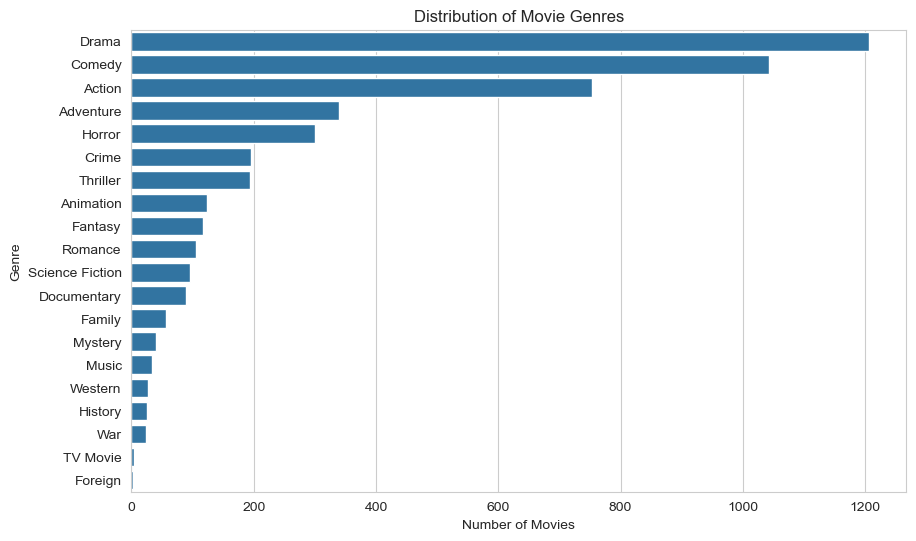

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)

plt.title("Distribution of Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

The distribution of movie genres is highly imbalanced. 
Drama and Comedy dominate the dataset, followed by Action, while many other genres appear far less frequently, such as Western, TV Movie ,and History.

This class imbalance may negatively affect machine learning models, since classifiers tend to favor the majority classes during training. 

To address this issue, I will focus on the most frequent genres in the dataset and filter out genres with very small sample sizes.

## 6. Filter Dataset to Top Genres
Some genres have very few samples, which can negatively affect model performance.
Therefore, I keep only the most frequent genres to create a more balanced dataset. This helps reduce extreme class imbalance and improves the stability of the classification models.

In [14]:
top8_genres = genre_counts.head(8).index
top8_genres

Index(['Drama', 'Comedy', 'Action', 'Adventure', 'Horror', 'Crime', 'Thriller',
       'Animation'],
      dtype='object', name='primary_genre')

In [15]:
df_filtered = df[df['primary_genre'].isin(top8_genres)]
df_filtered['primary_genre'].value_counts()

primary_genre
Drama        1207
Comedy       1042
Action        754
Adventure     339
Horror        300
Crime         195
Thriller      194
Animation     123
Name: count, dtype: int64

## 7. Text Preprocessing
Before converting text into numerical features, I clean and normalize the movie plot summaries to remove unnecessary characters and standardize the text, which helps improve the performance of machine learning models.

In [16]:
import re
import string

In [17]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\surface\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Handling Missing Values
Some movie plot summaries are missing in the dataset.
To prevent errors during preprocessing, non-string values are replaced with empty strings before applying text cleaning operations.

In [18]:
def clean_text(text):
   
    # handle missing values
    if not isinstance(text, str):
        return ""
        
    # convert to lowercase
    text = text.lower()

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = text.strip()

    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [19]:
df_filtered.loc[:, "clean_overview"] = df_filtered["overview"].apply(clean_text)

df_filtered[['overview','clean_overview']].head()

C:\Users\surface\AppData\Local\Temp\ipykernel_18592\3499420409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.loc[:, "clean_overview"] = df_filtered["overview"].apply(clean_text)


,overview,clean_overview
0,"In the 22nd century, a paraplegic Marine is di...",nd century paraplegic marine dispatched moon p...
1,"Captain Barbossa, long believed to be dead, ha...",captain barbossa long believed dead come back ...
2,A cryptic message from Bond’s past sends him o...,cryptic message bond’s past sends trail uncove...
3,Following the death of District Attorney Harve...,following death district attorney harvey dent ...
4,"John Carter is a war-weary, former military ca...",john carter warweary former military captain w...


## 8. Feature Engineering (TF-IDF)
To train machine learning models, textual data must be converted into numerical features.  
I use TF-IDF (Term Frequency-Inverse Document Frequency) to transform the cleaned movie plot summaries into vector representations.

TF-IDF highlights words that are important in a document but not too common across all documents.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Transform plot summaries into TF-IDF features
X = tfidf.fit_transform(df_filtered['clean_overview'])

# Target variable
y = df_filtered['primary_genre']

X.shape

(4154, 5000)

## 9. Train-Test Split
To evaluate the performance of the model, the dataset is divided into training and testing sets. The model will be trained on 80% of the data and evaluated on the remaining 20%.

In [22]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((3323, 5000), (831, 5000))

## 10. Model Traning 1: Logistic Regression
Logistic Regression is a commonly used baseline model for text classification, So I first train a standard logistic regression model using the TF-IDF features extracted from movie plot summaries.

In [23]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
model_baseline = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

# Train the model
model_baseline.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 11. Model Evaluation

### **Accuracy**
To evaluate the model's performance, we compute accuracy and generte a classification report including precision, recall, and F1-score for each genre.

In [24]:
# Predict genres for the test set
y_pred_baseline = model_baseline.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, f1_score

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average="macro")

print("Baseline Logistic Regression Accuracy:", baseline_accuracy)
print("Baseline Logistic Regression Macro F1:", baseline_macro_f1)

Baseline Logistic Regression Accuracy: 0.4332129963898917
Baseline Logistic Regression Macro F1: 0.21720152386471814


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

      Action       0.44      0.51      0.47       156
   Adventure       0.40      0.03      0.05        71
   Animation       0.00      0.00      0.00        21
      Comedy       0.49      0.61      0.55       205
       Crime       0.00      0.00      0.00        40
       Drama       0.38      0.69      0.49       213
      Horror       0.78      0.10      0.17        71
    Thriller       0.00      0.00      0.00        54

    accuracy                           0.43       831
   macro avg       0.31      0.24      0.22       831
weighted avg       0.40      0.43      0.37       831



C:\Users\surface\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\surface\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\surface\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### **Confusion Matrix**
To further analyze the model's predictions, we visualize the confusion matrix, which shows how often each genre is correctly classified or confused with others.

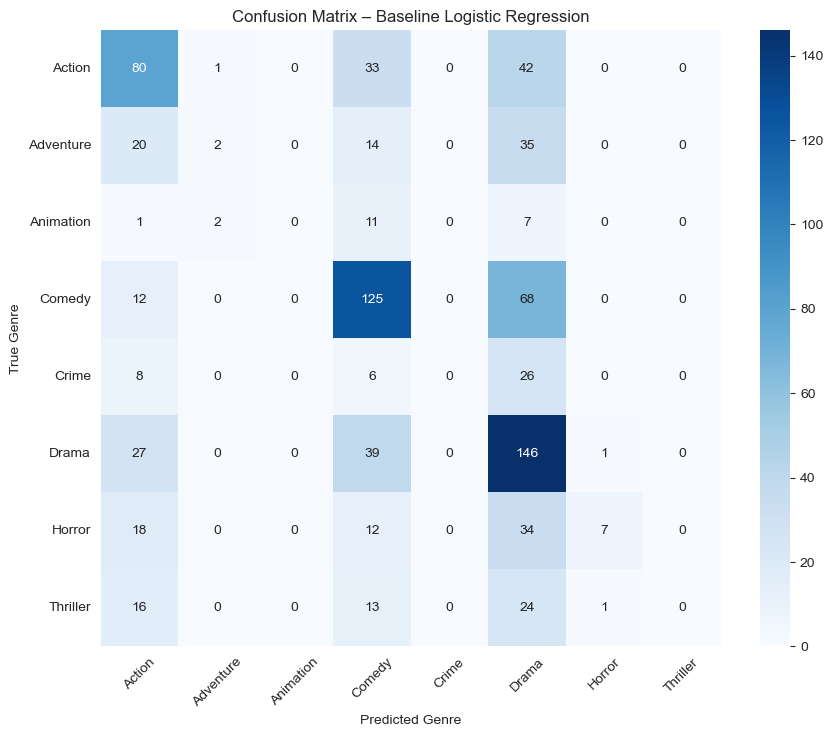

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = model_baseline.classes_

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_baseline, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=labels, 
    yticklabels=labels
)

plt.title("Confusion Matrix – Baseline Logistic Regression")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.savefig("confusion_matrix_baseline.png", dpi=300, bbox_inches="tight")

plt.show()

### Logistic Regression Performance Evaluation
The baseline logistic regression model achieves an accuracy of 0.43, with a macro F1-score of 0.22 and a weighted F1-score of 0.37. The model performs better on larger classes such as Comedy and Drama, but performs poorly on smaller genres.

From the classification report and confusion matrix, several classes such as Animation, Crime, and Thriller are rarely predicted. This suggests that the model is affected by **class imbalance**, where dominant genres receive most of the predictions.

## 12. Addressing Class Imbalance

### Method 1: Logistic regression with class weights 
To improve the model, we should next test a logistic regression model that accounts for class imbalance.

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

Accuracy: 0.46329723225030084
Macro F1: 0.3732297685463994


In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Action       0.50      0.51      0.50       156
   Adventure       0.35      0.39      0.37        71
   Animation       0.35      0.33      0.34        21
      Comedy       0.57      0.56      0.56       205
       Crime       0.12      0.12      0.12        40
       Drama       0.52      0.52      0.52       213
      Horror       0.42      0.54      0.47        71
    Thriller       0.15      0.07      0.10        54

    accuracy                           0.46       831
   macro avg       0.37      0.38      0.37       831
weighted avg       0.46      0.46      0.46       831



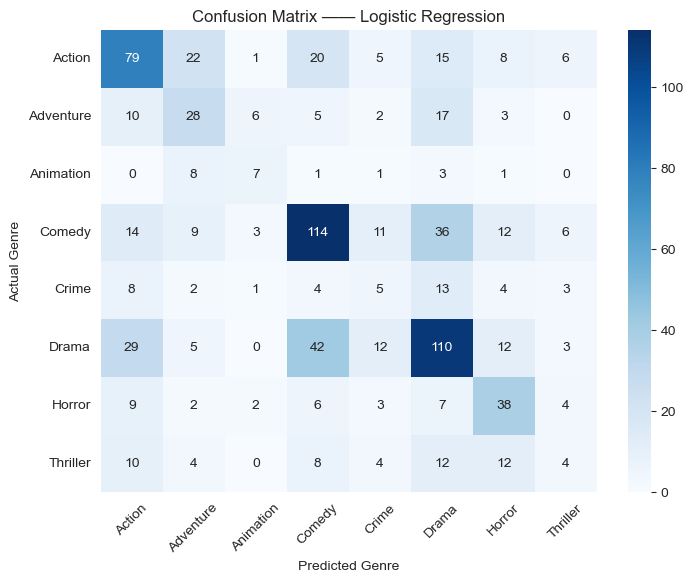

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = model.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=labels, 
    yticklabels=labels
)

plt.title("Confusion Matrix —— Logistic Regression")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

After applying class weights, the model shows improved performance compared to the baseline. The macro F1-score increases from 0.22 to 0.37, indicating better performance across minority genres. Several classes that previously received no predictions, such as Animation, Crime, and Thriller, now achieve non-zero recall and F1-scores.

### Method 2: Logistic regression trained on oversampled data
Another way to address class imbalance is to increase the number of samples from minority classes. Here I try to apply **Random Oversampling** to balance the training data before training the logistic regression model.

In [33]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Original training size:", X_train.shape)
print("Resampled training size:", X_train_ros.shape)

Original training size: (3323, 5000)
Resampled training size: (7952, 5000)


In [34]:
lr_ros = LogisticRegression(max_iter=1000)

lr_ros.fit(X_train_ros, y_train_ros)

y_pred_ros = lr_ros.predict(X_test)

In [35]:
print(classification_report(y_test, y_pred_ros))

              precision    recall  f1-score   support

      Action       0.50      0.51      0.51       156
   Adventure       0.36      0.31      0.33        71
   Animation       0.33      0.24      0.28        21
      Comedy       0.56      0.56      0.56       205
       Crime       0.15      0.15      0.15        40
       Drama       0.48      0.54      0.51       213
      Horror       0.44      0.49      0.47        71
    Thriller       0.17      0.07      0.10        54

    accuracy                           0.46       831
   macro avg       0.37      0.36      0.36       831
weighted avg       0.45      0.46      0.45       831



### Comparison of Approaches for Handling Class Imbalance
To evaluate whether the proposed approaches improve performance under class imbalance, we compare three models:

1. **Baseline Logistic Regression**
2. **Logistic Regression with class weights**
3. **Logistic Regression trained on oversampled data**

We evaluate these models using **accuracy** and **macro-averaged F1 score**, since macro F1 treats each genre equally and better reflects performance on imbalanced datasets.

In [36]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Logistic Regression (Class Weight)",
        "Logistic Regression (Oversampling)"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy,
        accuracy_score(y_test, y_pred_ros)
    ],
    "Macro F1": [
        baseline_macro_f1,
        macro_f1,
        f1_score(y_test, y_pred_ros, average="macro")
    ]
})

comparison

,Model,Accuracy,Macro F1
0,Baseline Logistic Regression,0.433213,0.217202
1,Logistic Regression (Class Weight),0.463297,0.373230
2,Logistic Regression (Oversampling),0.460890,0.362591


The baseline logistic regression shows lower macro F1 because the model tends to favor majority genres.  

Introducing **class weights** improves the macro F1 score by assigning higher importance to minority genres during training.  

Training on **oversampled data** further improves the balance of the dataset, allowing the model to learn more representative patterns for underrepresented genres.

## 13. Feature Importance Analysis
After evaluating the different models, we further analyze the trained logistic regression model to understand which textual features are most important for predicting movie genres.

The coefficients of the logistic regression model indicate how strongly each word contributes to the prediction. Examining these coefficients helps interpret how the model differentiates between genres based on textual information.

In [37]:
# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Get model coefficients
coefficients = model.coef_

# For each genre, print top important words
for i, genre in enumerate(model.classes_):
    
    top10 = coefficients[i].argsort()[-10:]
    
    print(f"\nTop words for genre: {genre}")
    
    for j in reversed(top10):
        print(feature_names[j])


Top words for genre: Action
criminals
cop
agent
government
assassin
former
earth
kill
elite
cia

Top words for genre: Adventure
bond
adventure
ship
boy
mission
powers
world
james
discovers
makes

Top words for genre: Animation
garfield
save
park
land
monsters
resort
ordinary
orphaned
dreams
quest

Top words for genre: Comedy
comedy
love
wedding
show
decides
women
friends
perfect
woman
gets

Top words for genre: Crime
police
murder
killer
brutal
fbi
corrupt
cartel
homicide
money
murders

Top words for genre: Drama
life
story
drama
wife
teacher
film
mother
women
war
love

Top words for genre: Horror
group
terrifying
jason
zombies
horror
begins
people
demonic
body
house

Top words for genre: Thriller
lake
robert
investment
computer
trafficking
truth
clues
mentally
justice
russian


The most important words extracted by the model mainly include genre-related terms such as "crime", "murder", "agent", and "zombies", which are strongly associated with specific movie genres.

Some words may correspond to character names (e.g., "James", "Jason", or "Robert"), but these appear less frequently than genre-specific terms.

This occurs because TF-IDF captures frequently occurring tokens in movie plot summaries. As a result, both genre-related keywords and occasionally character names may become important features for the model.

### Conclusion and Future Work

In this project, we developed a text classification model to predict movie genres from plot summaries using TF-IDF features and logistic regression. 

The baseline model showed limited performance due to class imbalance in the dataset. To address this issue, two approaches were explored: class weighting and random oversampling. The comparison results show that handling class imbalance improves the macro F1 score and leads to more balanced predictions across genres.

Feature importance analysis further demonstrates that the model captures meaningful genre-related keywords from movie plots.